For 8-bit RGB drone orthos:

| Laplacian var | Interpretation |
|---------------|----------------|
| < 500         | Very blurry    |
| 500 – 1500    | Soft           |
| 1500 – 4000   | Normal         |
| 4000 – 8000   | Sharp          |
| > 8000        | Very sharp     |


Available ortho files:
 1) A10Segment1.tif
 2) A58Segment2.tif
 3) A58Segment2_roadside.tif
 4) G15Segment1.tif



Select a file number:  1



Selected:
ORTHO_PATH = data_set/orthomosaic/A10Segment1.tif
OUT_DIR    = output/ortho_report/A10Segment1


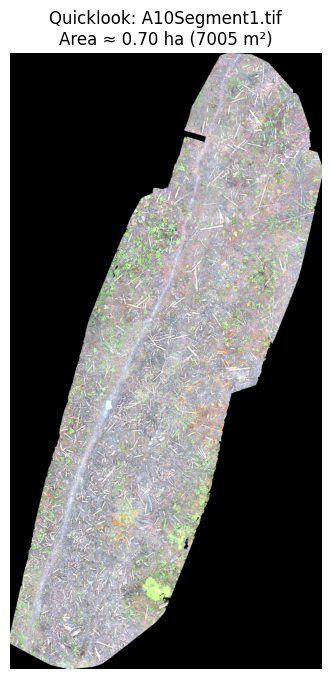


✅ Ortho report written: output/ortho_report/A10Segment1/report.json
🖼️ Quicklook: output/ortho_report/A10Segment1/quicklook.png
📏 GSD (approx): 0.15 cm/pixel
🗺️ CRS: EPSG:32610
📐 Coverage: 59.5 m × 117.8 m
🗺️ Area: 7005 m²  |  0.70 ha  |  0.0070 km²
🧪 Sampled ExG p50: 0.0
🔍 Sharpness (Laplacian var) p50: 887.5540161132812


In [1]:
# ============================================================
# RGB Ortho "Most Useful Info" extractor + Ortho picker
# ============================================================

from pathlib import Path
import json
import random

import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.enums import Resampling
import matplotlib.pyplot as plt


# ---------- SETTINGS ----------
ORTHO_FOLDER = Path("./data_set/orthomosaic")   # folder with ortho GeoTIFFs
REPORT_ROOT  = Path("./output/ortho_report")    # root folder for reports

RGB_BANDS  = (1, 2, 3)   # (R,G,B) band indices in the GeoTIFF
N_SAMPLES  = 30
WIN_SIZE   = 1024
BLACK_THRESH = 5         # for uint8; uint16 gets auto-adjusted
SEED = 7
# --------------------------------


# ---------- FILE PICKER ----------
def pick_ortho(ortho_folder: Path) -> Path:
    tifs = sorted(list(ortho_folder.glob("*.tif"))) + sorted(list(ortho_folder.glob("*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No .tif/.tiff files found in: {ortho_folder.resolve()}")

    print("\nAvailable ortho files:")
    for i, p in enumerate(tifs, 1):
        print(f"{i:2d}) {p.name}")

    choice = int(input("\nSelect a file number: "))
    if choice < 1 or choice > len(tifs):
        raise ValueError("Invalid selection.")

    return tifs[choice - 1]


# ---------- ANALYSIS HELPERS ----------
def _laplacian_variance(gray: np.ndarray) -> float:
    gray = gray.astype(np.float32)
    lap = (
        -4 * gray
        + np.roll(gray,  1, axis=0) + np.roll(gray, -1, axis=0)
        + np.roll(gray,  1, axis=1) + np.roll(gray, -1, axis=1)
    )
    return float(np.var(lap))

def _edge_density(gray: np.ndarray) -> float:
    gray = gray.astype(np.float32)
    gx = np.abs(np.diff(gray, axis=1, prepend=gray[:, :1]))
    gy = np.abs(np.diff(gray, axis=0, prepend=gray[:1, :]))
    g = gx + gy
    thr = np.percentile(g, 95)
    return float((g >= thr).mean())

def _rgb_indices(rgb: np.ndarray):
    rgb = rgb.astype(np.float32)
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    eps = 1e-6
    exg  = 2 * G - R - B
    vari = (G - R) / (G + R - B + eps)
    grvi = (G - R) / (G + R + eps)
    return exg, vari, grvi

def _summ_stats(x: np.ndarray):
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None
    return {
        "min": float(np.min(x)),
        "p2": float(np.percentile(x, 2)),
        "p50": float(np.percentile(x, 50)),
        "p98": float(np.percentile(x, 98)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
    }

def make_quicklook(src, out_png: Path, max_side=2000, return_array=True):
    """Create a quicklook RGB PNG by reading at reduced resolution.
    Saves PNG and optionally returns the uint8 RGB array for display.
    """
    w, h = src.width, src.height
    scale = max(w, h) / max_side
    if scale < 1:
        scale = 1
    out_w = int(w / scale)
    out_h = int(h / scale)

    rgb = src.read(
        RGB_BANDS,
        out_shape=(3, out_h, out_w),
        resampling=Resampling.bilinear
    )
    rgb = np.transpose(rgb, (1, 2, 0))

    # Normalize to uint8 for viewing (robust percentiles)
    rgb_f = rgb.astype(np.float32)
    p2 = np.percentile(rgb_f, 2, axis=(0, 1))
    p98 = np.percentile(rgb_f, 98, axis=(0, 1))
    rgb_n = (rgb_f - p2) / (p98 - p2 + 1e-6)
    rgb_u8 = np.clip(rgb_n * 255, 0, 255).astype(np.uint8)

    # Save PNG
    try:
        from PIL import Image
        Image.fromarray(rgb_u8).save(out_png)
    except ImportError:
        profile = {
            "driver": "PNG",
            "height": rgb_u8.shape[0],
            "width": rgb_u8.shape[1],
            "count": 3,
            "dtype": "uint8",
        }
        with rasterio.open(out_png, "w", **profile) as dst:
            for i in range(3):
                dst.write(rgb_u8[..., i], i + 1)

    if return_array:
        return rgb_u8
    return None


def analyze_rgb_ortho(ortho_path: Path, out_dir: Path):
    random.seed(SEED)
    np.random.seed(SEED)

    out_dir.mkdir(parents=True, exist_ok=True)

    report = {
        "ortho_path": str(ortho_path),
        "rgb_bands": RGB_BANDS,
        "samples": {"n_samples": N_SAMPLES, "window_size_px": WIN_SIZE},
        "metadata": {},
        "band_stats_sampled": {},
        "nodata_black_estimates": {},
        "rgb_indices_sampled": {},
        "sharpness_sampled": {},
        "notes": [
            "Stats computed from random windows to stay fast on huge orthomosaics.",
            "If you want full-raster stats, I can provide a block-wise pass (slower)."
        ]
    }

    with rasterio.open(ortho_path) as src:
        resx, resy = src.res
        crs = src.crs.to_string() if src.crs else None
        
        bounds = src.bounds
        resx, resy = src.res
        crs = src.crs.to_string() if src.crs else None
        
        # Coverage dimensions in meters:
        # If bounds are in meters (UTM), this is direct. Otherwise fall back to pixel-based estimate.
        width_m_bounds  = (bounds.right - bounds.left) if crs else None
        height_m_bounds = (bounds.top - bounds.bottom) if crs else None
        
        # Pixel-based estimate (works when CRS units are meters; still useful as estimate)
        width_m_px  = src.width  * float(resx)
        height_m_px = src.height * float(resy)
        
        # Choose bounds-based if available, else pixel-based
        width_m  = float(width_m_bounds) if width_m_bounds is not None else float(width_m_px)
        height_m = float(height_m_bounds) if height_m_bounds is not None else float(height_m_px)
        
        area_m2 = width_m * height_m
        area_ha = area_m2 / 10_000
        area_km2 = area_m2 / 1_000_000

        report["metadata"] = {
            "driver": src.driver,
            "dtype_per_band": src.dtypes,
            "band_count": src.count,
            "width_px": src.width,
            "height_px": src.height,
            "crs": crs,
            "pixel_size_x": float(resx),
            "pixel_size_y": float(resy),
            "bounds": {
                "left": float(bounds.left),
                "bottom": float(bounds.bottom),
                "right": float(bounds.right),
                "top": float(bounds.top),
            },
            "coverage_width_m": width_m,
            "coverage_height_m": height_m,
            "coverage_area_m2": area_m2,
            "coverage_area_ha": area_ha,
            "coverage_area_km2": area_km2,
            "nodata": src.nodata,
        }

        dtype0 = src.dtypes[RGB_BANDS[0]-1] if src.dtypes else "uint8"
        black_thr = int(0.01 * 65535) if "uint16" in str(dtype0) else BLACK_THRESH

        H, W = src.height, src.width
        win = WIN_SIZE

        cap_pixels = 2_000_000
        R_all, G_all, B_all = [], [], []
        exg_all, vari_all, grvi_all = [], [], []
        black_fracs, nodata_fracs = [], []
        sharp_vals, edge_vals = [], []

        def add_cap(lst, arr):
            if arr.size == 0:
                return
            if sum(x.size for x in lst) >= cap_pixels:
                return
            lst.append(arr.reshape(-1))

        for _ in range(N_SAMPLES):
            if W <= win or H <= win:
                x0, y0 = 0, 0
                w0, h0 = W, H
            else:
                x0 = random.randint(0, W - win)
                y0 = random.randint(0, H - win)
                w0, h0 = win, win

            window = Window(x0, y0, w0, h0)
            rgb = src.read(RGB_BANDS, window=window)
            rgb = np.transpose(rgb, (1, 2, 0))

            if src.nodata is not None:
                nod_mask = np.any(rgb == src.nodata, axis=2)
                nodata_fracs.append(float(nod_mask.mean()))
            else:
                nodata_fracs.append(None)

            black_mask = np.all(rgb <= black_thr, axis=2)
            black_fracs.append(float(black_mask.mean()))

            valid = ~black_mask
            if src.nodata is not None:
                valid = valid & (~np.any(rgb == src.nodata, axis=2))

            if valid.sum() < 100:
                continue

            rgb_v = rgb[valid]
            add_cap(R_all, rgb_v[:, 0])
            add_cap(G_all, rgb_v[:, 1])
            add_cap(B_all, rgb_v[:, 2])

            exg, vari, grvi = _rgb_indices(rgb.astype(np.float32))
            add_cap(exg_all, exg[valid])
            add_cap(vari_all, vari[valid])
            add_cap(grvi_all, grvi[valid])

            gray = (0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]).astype(np.float32)
            gray_v = gray.copy()
            gray_v[~valid] = np.nan
            med = np.nanmedian(gray_v)
            gray_fill = np.where(np.isfinite(gray_v), gray_v, med)

            sharp_vals.append(_laplacian_variance(gray_fill))
            edge_vals.append(_edge_density(gray_fill))

        def cat(lst):
            return np.concatenate(lst) if len(lst) else np.array([], dtype=np.float32)

        R = cat(R_all); G = cat(G_all); B = cat(B_all)
        exg = cat(exg_all); vari = cat(vari_all); grvi = cat(grvi_all)

        report["band_stats_sampled"] = {"R": _summ_stats(R), "G": _summ_stats(G), "B": _summ_stats(B)}
        report["rgb_indices_sampled"] = {"ExG": _summ_stats(exg), "VARI": _summ_stats(vari), "GRVI": _summ_stats(grvi)}

        bf = np.array([x for x in black_fracs if x is not None], dtype=float)
        nf = np.array([x for x in nodata_fracs if x is not None], dtype=float)

        report["nodata_black_estimates"] = {
            "black_threshold_used": black_thr,
            "black_fraction_mean": float(np.mean(bf)) if bf.size else None,
            "black_fraction_p50": float(np.percentile(bf, 50)) if bf.size else None,
            "black_fraction_p95": float(np.percentile(bf, 95)) if bf.size else None,
            "nodata_fraction_mean": float(np.mean(nf)) if nf.size else None,
            "nodata_fraction_p50": float(np.percentile(nf, 50)) if nf.size else None,
            "nodata_fraction_p95": float(np.percentile(nf, 95)) if nf.size else None,
        }

        sv = np.array(sharp_vals, dtype=float)
        ev = np.array(edge_vals, dtype=float)
        report["sharpness_sampled"] = {
            "laplacian_variance_mean": float(np.mean(sv)) if sv.size else None,
            "laplacian_variance_p50": float(np.percentile(sv, 50)) if sv.size else None,
            "laplacian_variance_p10": float(np.percentile(sv, 10)) if sv.size else None,
            "laplacian_variance_p90": float(np.percentile(sv, 90)) if sv.size else None,
            "edge_density_mean": float(np.mean(ev)) if ev.size else None,
            "edge_density_p50": float(np.percentile(ev, 50)) if ev.size else None,
        }

        quicklook_png = out_dir / "quicklook.png"
        quicklook_u8 = make_quicklook(src, quicklook_png, max_side=2000, return_array=True)
        
        # Show the quicklook in notebook
        plt.figure(figsize=(8, 8))
        plt.imshow(quicklook_u8)
        plt.title(f"Quicklook: {Path(ortho_path).name}\nArea ≈ {area_ha:.2f} ha ({area_m2:.0f} m²)")
        plt.axis("off")
        plt.show()
       
        report["outputs"] = {
            "report_json": str(out_dir / "report.json"),
            "quicklook_png": str(quicklook_png),
        }

    with open(out_dir / "report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    gsd_cm = report["metadata"]["pixel_size_x"] * 100
    print("\n✅ Ortho report written:", out_dir / "report.json")
    print("🖼️ Quicklook:", out_dir / "quicklook.png")
    print(f"📏 GSD (approx): {gsd_cm:.2f} cm/pixel")
    print(f"🗺️ CRS: {report['metadata']['crs']}")
    print(f"📐 Coverage: {width_m:.1f} m × {height_m:.1f} m")
    print(f"🗺️ Area: {area_m2:.0f} m²  |  {area_ha:.2f} ha  |  {area_km2:.4f} km²")
    if report["rgb_indices_sampled"]["ExG"]:
        print("🧪 Sampled ExG p50:", report["rgb_indices_sampled"]["ExG"]["p50"])
    print("🔍 Sharpness (Laplacian var) p50:", report["sharpness_sampled"]["laplacian_variance_p50"])

    return report


# ===========================
# MAIN: pick file then run
# ===========================
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

ORTHO_PATH = pick_ortho(ORTHO_FOLDER)
OUT_DIR = REPORT_ROOT / ORTHO_PATH.stem

print("\nSelected:")
print("ORTHO_PATH =", ORTHO_PATH)
print("OUT_DIR    =", OUT_DIR)

report = analyze_rgb_ortho(ORTHO_PATH, OUT_DIR)

In [2]:
# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt

# with rasterio.open("./data_set/orthomosaic/G15Segment1.tif") as src:
#     img = src.read([1,2,3])

# img = np.transpose(img, (1,2,0))
# plt.imshow(img)
# plt.title("Ortho")
# plt.show()